<a href="https://colab.research.google.com/github/PinderMaksim/6.1.1/blob/main/laba7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
           'marital-status', 'occupation', 'relationship', 'race',
           'sex', 'capital-gain', 'capital-loss', 'hours-per-week',
           'native-country', 'income_>50K']

data = pd.read_csv(url,names=columns,sep=',\s',engine='python')

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_21157/1521170408.py:8: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv(url,names=columns,sep=',\s',engine='python')


In [3]:
print("Перші 5 записів:")
print(data.head())

Перші 5 записів:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income_>50K  
0          2174             0              40  United-States       <=50K  
1             0

In [4]:
to_factor = ['workclass','education','marital-status','occupation','relationship','race','sex','native-country']
data[to_factor] = data[to_factor].apply(lambda col: pd.factorize(col, sort=True)[0])

In [5]:
print("\nЗбалансованість класів:")
print(data['income_>50K'].value_counts(normalize=True))


Збалансованість класів:
income_>50K
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64


In [6]:
X = data.drop('income_>50K', axis=1)

Y = pd.get_dummies(data['income_>50K'])

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15)

In [16]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [10]:
from tensorflow.keras.layers import Input

model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(16, activation="relu"))
model.add(Dense(8, activation="relu"))
model.add(Dense(2, activation="softmax"))

In [11]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, Y_train, epochs=30, validation_split=0.15)

Epoch 1/30
736/736 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7950 - loss: 0.4247 - val_accuracy: 0.8309 - val_loss: 0.3572
Epoch 2/30
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8374 - loss: 0.3436 - val_accuracy: 0.8427 - val_loss: 0.3316
Epoch 3/30
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8412 - loss: 0.3334 - val_accuracy: 0.8432 - val_loss: 0.3259
Epoch 4/30
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8447 - loss: 0.3294 - val_accuracy: 0.8449 - val_loss: 0.3232
Epoch 5/30
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8447 - loss: 0.3273 - val_accuracy: 0.8447 - val_loss: 0.3228
Epoch 6/30
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8465 - loss: 0.3259 - val_accuracy: 0.8442 - val_loss: 0.3220
Epoch 7/30
736/736 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8463 - loss: 0.3242 - val_accuracy: 0.8471 - val_loss: 0.3211
Epoch 8/30
736/736 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8469 - loss: 0.3235 - val_accuracy: 0.

In [12]:
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)

print(f"Точність моделі на тестових даних: {accuracy*100:.2f}%")

Точність моделі на тестових даних: 85.06%


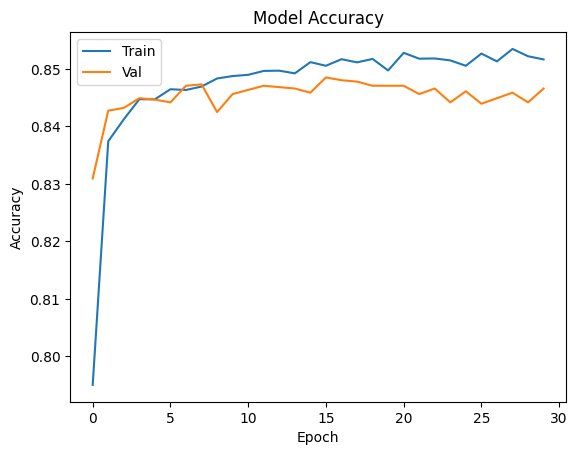

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epoch')

plt.legend(['Train', 'Val'], loc='upper left')

plt.show()

In [14]:
sample = X_test[0:1]

prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

probability = np.max(prediction) * 100

print(f"Передбачено клас {predicted_class} з достовірністю {probability:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Передбачено клас 0 з достовірністю 99.63%
